In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization

from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

I0000 00:00:1790238610.008338   74378 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790238610.049920   74378 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790238611.161666   74378 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Load the data

In [2]:
(X_train, y_train),_ = cifar10.load_data()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)


In [3]:
# Define the labels of the dataset
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
          'dog', 'frog', 'horse', 'ship', 'truck']

Text(0.5, 1.0, 'Class distribution in training set')

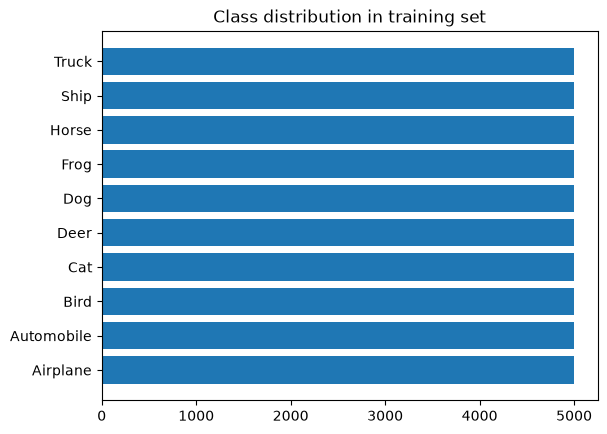

In [4]:
classes_name = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

classes, counts = np.unique(y_train, return_counts=True)
plt.barh(classes_name, counts)
plt.title('Class distribution in training set')


The class are equally distributed


# Data Preprocessing

In [5]:
# Scale the data
X_train = X_train / 255.0

# Split training data into train (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=23092026,
    stratify=y_train
)

# Transform target variable into one-hotencoding
y_cat_train = to_categorical(y_train, 10)
y_cat_val = to_categorical(y_val, 10)

print(f"X_train shape: {X_train.shape}, y_cat_train shape: {y_cat_train.shape}")
print(f"X_val shape  : {X_val.shape}, y_cat_val shape  : {y_cat_val.shape}")


X_train shape: (40000, 32, 32, 3), y_cat_train shape: (40000, 10)
X_val shape  : (10000, 32, 32, 3), y_cat_val shape  : (10000, 10)


In [6]:
y_cat_train

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

# Model Building

In [7]:
INPUT_SHAPE = (32, 32, 3)
KERNEL_SIZE = (3, 3)

def build_model(dense_units=128, dropout_rate=0.25):
    model = Sequential([
        # Top-level Input layer (eliminates Keras 3 input_shape warnings)
        Input(shape=INPUT_SHAPE),

        # Block 1
        Conv2D(filters=32, kernel_size=KERNEL_SIZE, activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(filters=32, kernel_size=KERNEL_SIZE, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPool2D(pool_size=(2, 2)),
        Dropout(dropout_rate),

        # Block 2
        Conv2D(filters=64, kernel_size=KERNEL_SIZE, activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(filters=64, kernel_size=KERNEL_SIZE, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPool2D(pool_size=(2, 2)),
        Dropout(dropout_rate),

        # Block 3
        Conv2D(filters=128, kernel_size=KERNEL_SIZE, activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(filters=128, kernel_size=KERNEL_SIZE, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPool2D(pool_size=(2, 2)),
        Dropout(dropout_rate),

        # Classification Head
        Flatten(),
        Dense(dense_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(10, activation='softmax')
    ])

    METRICS = [
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=METRICS)
    return model

## Hyperparameter Tuning with GridSearch

In [8]:
# 1. Evaluate Baseline Model (Before GridSearch: dense_units=128, dropout_rate=0.25)
print("--- 1. Evaluating Baseline Model (Before GridSearch) ---")
baseline_model = build_model(dense_units=128, dropout_rate=0.25)

batch_size = 32
baseline_datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)
baseline_train_gen = baseline_datagen.flow(X_train, y_cat_train, batch_size=batch_size)
steps_per_epoch = X_train.shape[0] // batch_size

baseline_history = baseline_model.fit(
    baseline_train_gen,
    epochs=10,
    steps_per_epoch=steps_per_epoch,
    validation_data=(X_val, y_cat_val),
    verbose=1
)

baseline_eval = baseline_model.evaluate(X_val, y_cat_val, verbose=0)
baseline_val_loss = baseline_eval[0]
baseline_val_acc = baseline_eval[1]
print(f"\nBaseline (Before GridSearch) -> Val Loss: {baseline_val_loss:.4f}, Val Accuracy: {baseline_val_acc * 100:.2f}%")

--- 1. Evaluating Baseline Model (Before GridSearch) ---


I0000 00:00:1790238613.654798   74378 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2920 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/10


I0000 00:00:1790238614.585030   74378 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1790238616.930082   74448 service.cc:153] XLA service 0x74abc80416a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790238616.930103   74448 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790238616.991255   74448 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790238617.480886   74448 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1790238617.600033   74448 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6146__.88


  21/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.1384 - loss: 3.0920 - precision: 0.1486 - recall: 0.0387

I0000 00:00:1790238627.608863   74448 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - accuracy: 0.3822 - loss: 1.7079 - precision: 0.5910 - recall: 0.1639 - val_accuracy: 0.4705 - val_loss: 1.5736 - val_precision: 0.5758 - val_recall: 0.3419
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5295 - loss: 1.3123 - precision: 0.7066 - recall: 0.3514 - val_accuracy: 0.6034 - val_loss: 1.1040 - val_precision: 0.7524 - val_recall: 0.4871
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6125 - loss: 1.1054 - precision: 0.7588 - recall: 0.4679 - val_accuracy: 0.5792 - val_loss: 1.2020 - val_precision: 0.6862 - val_recall: 0.4887
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6550 - loss: 0.9970 - precision: 0.7850 - recall: 0.5301 - val_accuracy: 0.7038 - val_loss: 0.8517 - val_precision: 0.8107 - val_recall: 0.6079
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6840 - loss: 0.9185 - precision: 0.8019 - recall: 0.5758 - val_accuracy: 0.7209 - val_

In [9]:
# 2. Running GridSearchCV (10 Epochs)
print("--- 2. Running GridSearchCV (10 Epochs) ---")
grid_samples = 6000
X_grid = X_train[:grid_samples]
y_grid = y_cat_train[:grid_samples]

grid_model = KerasClassifier(model=build_model, epochs=10, batch_size=64, verbose=1)

param_grid = {
    'model__dense_units': [128, 256],
    'model__dropout_rate': [0.25, 0.35]
}

cv = KFold(n_splits=2, shuffle=True, random_state=23092026)
grid = GridSearchCV(estimator=grid_model, param_grid=param_grid, cv=cv, verbose=1)
grid_result = grid.fit(X_grid, y_grid)

print(f"\nBest parameters: {grid_result.best_params_}")
print(f"Best CV Score: {grid_result.best_score_:.4f}")

# Extract parameters using the SciKeras 'model__' prefix
best_dense = grid_result.best_params_.get('model__dense_units', 128)
best_dropout = grid_result.best_params_.get('model__dropout_rate', 0.25)
print(f"Selected parameters for final training: dense_units={best_dense}, dropout_rate={best_dropout}")

--- 2. Running GridSearchCV (10 Epochs) ---
Fitting 2 folds for each of 4 candidates, totalling 8 fits
Epoch 1/10


I0000 00:00:1790238758.866378   74449 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_109687__.88


45/47 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2316 - loss: 2.3270 - precision: 0.2823 - recall: 0.0538

I0000 00:00:1790238770.552822   74448 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_109687__.88


47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 245ms/step - accuracy: 0.2333 - loss: 2.3108 - precision: 0.2969 - recall: 0.0570
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3243 - loss: 1.8157 - precision: 0.5134 - recall: 0.1083
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3960 - loss: 1.6812 - precision: 0.5928 - recall: 0.1650
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4303 - loss: 1.5588 - precision: 0.6462 - recall: 0.2210
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4620 - loss: 1.4791 - precision: 0.6483 - recall: 0.2623
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4993 - loss: 1.3992 - precision: 0.6687 - recall: 0.2993
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5243 - loss: 1.3053 - precision: 0.6900 - recall: 0.3450
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5553 - loss: 1.2219 - precision: 0.7249 - recall: 0.3917
Epoch 9/10
47/47 ━━━━━━━━━━━━━━━━

...

47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - accuracy: 0.2037 - loss: 2.6777 - precision: 0.2193 - recall: 0.0470
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2923 - loss: 1.9414 - precision: 0.4827 - recall: 0.0790
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3397 - loss: 1.8120 - precision: 0.4775 - recall: 0.1063
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3810 - loss: 1.6758 - precision: 0.5964 - recall: 0.1660
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4027 - loss: 1.6033 - precision: 0.6036 - recall: 0.1903
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4360 - loss: 1.5423 - precision: 0.6275 - recall: 0.2263
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4597 - loss: 1.4731 - precision: 0.6297 - recall: 0.2653
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4843 - loss: 1.4069 - precision: 0.6596 - recall: 0.2997
Epoch 9/10
47/47 ━━━━━━━━━━━━━━━━

I0000 00:00:1790238949.677903   74450 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_194271__.88


90/94 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2677 - loss: 2.0755 - precision: 0.4190 - recall: 0.0628

I0000 00:00:1790238956.180173   74449 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_194271__.88


94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 128ms/step - accuracy: 0.2682 - loss: 2.0663 - precision: 0.4161 - recall: 0.0628
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3803 - loss: 1.6977 - precision: 0.5776 - recall: 0.1495
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4272 - loss: 1.5596 - precision: 0.6272 - recall: 0.2067
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4800 - loss: 1.4342 - precision: 0.6688 - recall: 0.2787
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5070 - loss: 1.3437 - precision: 0.6756 - recall: 0.3168
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5528 - loss: 1.2524 - precision: 0.7080 - recall: 0.3730
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5740 - loss: 1.1668 - precision: 0.7304 - recall: 0.4195
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6008 - loss: 1.1018 - precision: 0.7362 - recall: 0.4567
Epoch 9/10
94/94 ━━━━━━━━━━━━━━━━

In [10]:
model = build_model(dense_units=best_dense, dropout_rate=best_dropout)
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,29

 Total params: 552,362 (2.11 MB)

 Trainable params: 551,466 (2.10 MB)

 Non-trainable params: 896 (3.50 KB)

## Early Stopping

In [11]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)

## Data Augmentations

In [12]:
batch_size = 32
data_generator = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)
train_generator = data_generator.flow(X_train, y_cat_train, batch_size)
steps_per_epoch = X_train.shape[0] // batch_size

r = model.fit(train_generator, 
              epochs=10,
              steps_per_epoch=steps_per_epoch,
              validation_data=(X_val, y_cat_val), 
             )

Epoch 1/10


I0000 00:00:1790238979.593665   74449 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_206717__.88


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.3862 - loss: 1.6858 - precision: 0.6065 - recall: 0.1765 - val_accuracy: 0.5191 - val_loss: 1.3680 - val_precision: 0.6844 - val_recall: 0.3791
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5395 - loss: 1.2960 - precision: 0.7184 - recall: 0.3618 - val_accuracy: 0.6148 - val_loss: 1.0886 - val_precision: 0.7736 - val_recall: 0.4916
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6119 - loss: 1.1050 - precision: 0.7632 - recall: 0.4670 - val_accuracy: 0.6555 - val_loss: 0.9944 - val_precision: 0.7611 - val_recall: 0.5531
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6573 - loss: 0.9927 - precision: 0.7855 - recall: 0.5336 - val_accuracy: 0.7287 - val_loss: 0.7692 - val_precision: 0.8463 - val_recall: 0.6240
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6859 - loss: 0.9095 - precision: 0.7992 - recall: 0.5775 - val_accuracy: 0.7142 - val_lo

# Model Evaluation

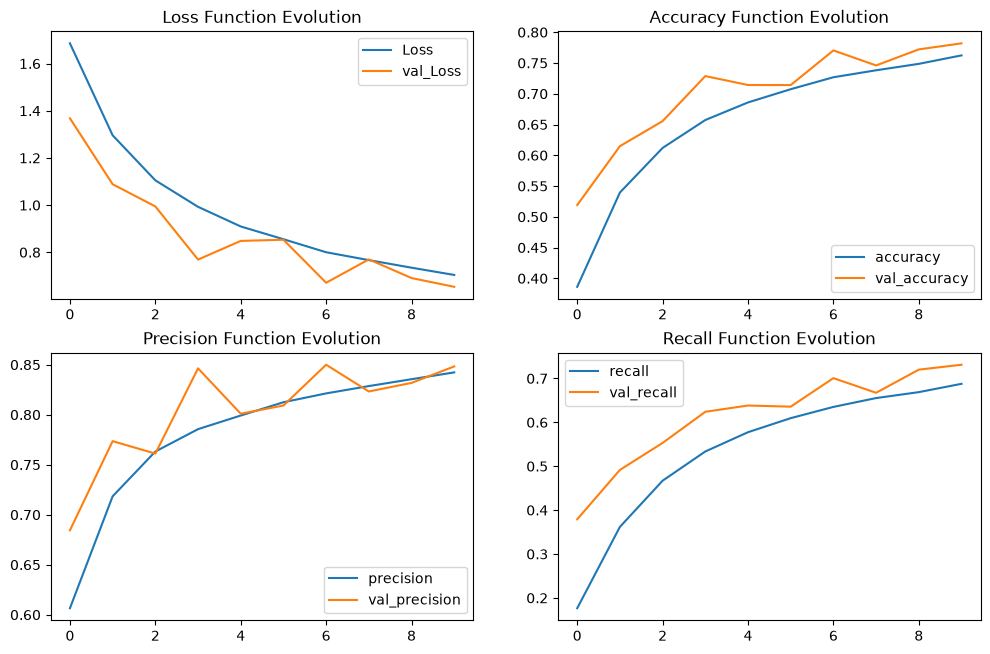

In [13]:
plt.figure(figsize=(12, 16))

plt.subplot(4, 2, 1)
plt.plot(r.history['loss'], label='Loss')
plt.plot(r.history['val_loss'], label='val_Loss')
plt.title('Loss Function Evolution')
plt.legend()

plt.subplot(4, 2, 2)
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Function Evolution')
plt.legend()

plt.subplot(4, 2, 3)
plt.plot(r.history['precision'], label='precision')
plt.plot(r.history['val_precision'], label='val_precision')
plt.title('Precision Function Evolution')
plt.legend()

plt.subplot(4, 2, 4)
plt.plot(r.history['recall'], label='recall')
plt.plot(r.history['val_recall'], label='val_recall')
plt.title('Recall Function Evolution')
plt.legend()


     MODEL PERFORMANCE COMPARISON: BEFORE vs AFTER GRID SEARCH
 Before GridSearch (Baseline: 128 units, drop 0.25) : Val Acc = 77.30%, Val Loss = 0.6602
 After GridSearch  (Tuned: 128 units, drop 0.25)       : Val Acc = 78.19%, Val Loss = 0.6536
 Accuracy Improvement (+Delta)                       : +0.89%


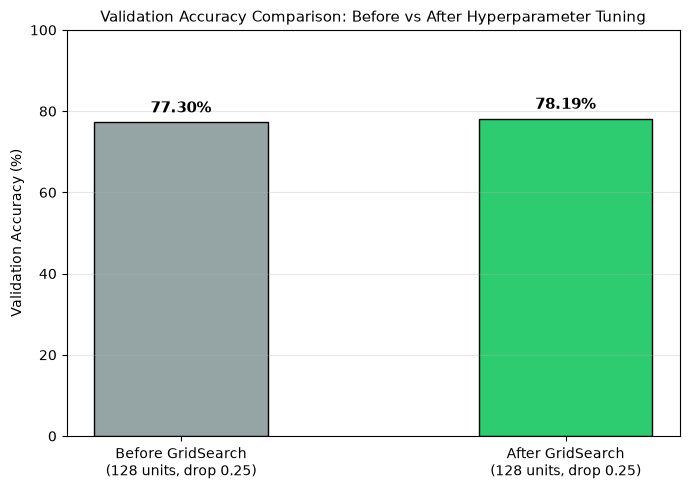

In [14]:
# Evaluate Tuned Model performance
tuned_eval = model.evaluate(X_val, y_cat_val, verbose=0)
tuned_val_loss = tuned_eval[0]
tuned_val_acc = tuned_eval[1]

acc_improvement = (tuned_val_acc - baseline_val_acc) * 100

print("=" * 65)
print("     MODEL PERFORMANCE COMPARISON: BEFORE vs AFTER GRID SEARCH")
print("=" * 65)
print(f" Before GridSearch (Baseline: 128 units, drop 0.25) : Val Acc = {baseline_val_acc * 100:.2f}%, Val Loss = {baseline_val_loss:.4f}")
print(f" After GridSearch  (Tuned: {best_dense} units, drop {best_dropout})       : Val Acc = {tuned_val_acc * 100:.2f}%, Val Loss = {tuned_val_loss:.4f}")
print(f" Accuracy Improvement (+Delta)                       : {acc_improvement:+.2f}%")
print("=" * 65)

# Visual comparison via bar chart
categories = [
    'Before GridSearch\n(128 units, drop 0.25)', 
    f'After GridSearch\n({best_dense} units, drop {best_dropout})'
]
acc_values = [baseline_val_acc * 100, tuned_val_acc * 100]

plt.figure(figsize=(7, 5))
bars = plt.bar(categories, acc_values, color=['#95a5a6', '#2ecc71'], width=0.45, edgecolor='black')
plt.ylabel('Validation Accuracy (%)')
plt.title('Validation Accuracy Comparison: Before vs After Hyperparameter Tuning', fontsize=11)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 1.5,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 7. Save the models

In [15]:
model.save('custom_cnn_10_epochs.h5')
print("Model saved to custom_cnn_10_epochs.h5")


Model saved to custom_cnn_10_epochs.h5
